# Insurance Cross-Sell Targeting
Which health-insurance customers are worth calling to sell vehicle insurance?

Data: Kaggle *Health Insurance Cross Sell Prediction* (download `train.csv` and upload it in the cell below).

**Steps:** 1) Setup and data, 2) Model and ranking by score, 3) Calibration, 4) Profit and cutoff, 5) What drives the score (SHAP), 6) Test sample size, 7) Export for Power BI.

In [ ]:
!pip install shap

In [ ]:
!pip install lightgbm

In [ ]:
from google.colab import files
   files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip -o archive.zip

Archive:  archive.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

df = pd.read_csv("train.csv")

# Prepare (no premium cap yet)
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["Vehicle_Damage"] = df["Vehicle_Damage"].map({"No": 0, "Yes": 1})
df["Vehicle_Age"] = df["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
df["Premium_At_Floor"] = (df["Annual_Premium"] == 2630).astype(int)
df["Region_Code"] = df["Region_Code"].astype(int).astype("category")
df["Policy_Sales_Channel"] = df["Policy_Sales_Channel"].astype(int).astype("category")

X = df.drop(columns=["id", "Response"])
y = df["Response"]

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Cap from the training data only, then apply the same cap to both
cap = X_train["Annual_Premium"].quantile(0.99)
print("Premium cap (from training data only):", round(cap))
X_train = X_train.copy(); X_test = X_test.copy()
X_train["Annual_Premium"] = X_train["Annual_Premium"].clip(upper=cap)
X_test["Annual_Premium"] = X_test["Annual_Premium"].clip(upper=cap)

print("Train:", X_train.shape, "| Test:", X_test.shape)

# Train
model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                           random_state=42, verbose=-1)
model.fit(X_train, y_train)

# Judge
p = model.predict_proba(X_test)[:, 1]
print("\nROC-AUC:", round(roc_auc_score(y_test, p), 4))

res = pd.DataFrame({"y": y_test.values, "p": p})
res["decile"] = pd.qcut(res["p"].rank(method="first", ascending=False), 10, labels=range(1, 11))
base = res["y"].mean()
tab = res.groupby("decile", observed=True).agg(customers=("y", "size"), buyers=("y", "sum"))
tab["yes_rate_%"] = (tab["buyers"] / tab["customers"] * 100).round(1)
tab["lift"] = (tab["buyers"] / tab["customers"] / base).round(2)
tab["cum_buyers_captured_%"] = (tab["buyers"].cumsum() / tab["buyers"].sum() * 100).round(1)
print(tab)

Premium cap (from training data only): 73132
Train: (304887, 11) | Test: (76222, 11)

ROC-AUC: 0.8582
        customers  buyers  yes_rate_%  lift  cum_buyers_captured_%
decile                                                            
1            7623    3017        39.6  3.23                   32.3
2            7622    2441        32.0  2.61                   58.4
3            7622    1927        25.3  2.06                   79.1
4            7622    1279        16.8  1.37                   92.7
5            7622     580         7.6  0.62                   99.0
6            7622      89         1.2  0.10                   99.9
7            7622       2         0.0  0.00                   99.9
8            7622       4         0.1  0.00                  100.0
9            7622       1         0.0  0.00                  100.0
10           7623       2         0.0  0.00                  100.0


In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import pandas as pd

# Split the training data again: 75% to fit the model, 25% to learn the correction
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=7)

model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                           random_state=42, verbose=-1)
model.fit(X_fit, y_fit)

p_cal = model.predict_proba(X_cal)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]

# Learn a correction curve on the calibration part, apply it to the test part
iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, y_cal)
p_test_iso = iso.predict(p_test)

def table(p, y, name):
    d = pd.DataFrame({"p": p, "y": y.values})
    d["bin"] = pd.cut(d["p"], [0, .05, .1, .2, .3, .4, .5, .6, 1.0], include_lowest=True)
    g = d.groupby("bin", observed=True)
    t = g.agg(customers=("y", "size"), avg_predicted=("p", "mean"), actual_rate=("y", "mean")).round(3)
    gap = (abs(g["p"].mean() - g["y"].mean()) * g.size() / len(d)).sum()
    print(f"\n{name}"); print(t); print("Avg gap (predicted vs actual):", round(gap, 4))

print("AUC before:", round(roc_auc_score(y_test, p_test), 4), "| after:", round(roc_auc_score(y_test, p_test_iso), 4))
print("Brier before:", round(brier_score_loss(y_test, p_test), 5), "| after:", round(brier_score_loss(y_test, p_test_iso), 5))
print("Mean predicted before:", round(p_test.mean(), 4), "| after:", round(p_test_iso.mean(), 4), "| actual:", round(y_test.mean(), 4))
table(p_test, y_test, "BEFORE calibration")
table(p_test_iso, y_test, "AFTER calibration")

AUC before: 0.8568 | after: 0.8568
Brier before: 0.0868 | after: 0.08677
Mean predicted before: 0.1221 | after: 0.1216 | actual: 0.1226

BEFORE calibration
                customers  avg_predicted  actual_rate
bin                                                  
(-0.001, 0.05]      40045          0.004        0.004
(0.05, 0.1]          4329          0.076        0.080
(0.1, 0.2]           8010          0.151        0.156
(0.2, 0.3]          10690          0.254        0.261
(0.3, 0.4]           9651          0.347        0.348
(0.4, 0.5]           3085          0.435        0.402
(0.5, 0.6]            389          0.526        0.463
(0.6, 1.0]             23          0.640        0.435
Avg gap (predicted vs actual): 0.004

AFTER calibration
                customers  avg_predicted  actual_rate
bin                                                  
(-0.001, 0.05]      40215          0.004        0.004
(0.05, 0.1]          4561          0.080        0.085
(0.1, 0.2]           6714       

In [ ]:
import numpy as np, pandas as pd

PROFIT_PER_SALE = 2000   # ASSUMPTION: profit per vehicle policy sold (Rs). Change it.
COST_PER_CONTACT = 100   # ASSUMPTION: cost of one call (Rs). Change it.

d = pd.DataFrame({"p": p_test_iso, "y": y_test.values})
d["exp_profit"] = d["p"] * PROFIT_PER_SALE - COST_PER_CONTACT
d["real_profit"] = d["y"] * PROFIT_PER_SALE - COST_PER_CONTACT

d = d.sort_values("exp_profit", ascending=False).reset_index(drop=True)
d["cum_real_profit"] = d["real_profit"].cumsum()
d["cum_buyers"] = d["y"].cumsum()
n = len(d)

print(f"Break-even probability: {COST_PER_CONTACT / PROFIT_PER_SALE:.1%}")
best_n = int((d["exp_profit"] > 0).sum())
print(f"Customers with positive expected profit: {best_n:,} of {n:,} ({best_n/n:.1%})")

def result(label, k, buyers, profit):
    print(f"{label:<36}{k:>8,}{buyers:>9,}{profit:>15,.0f}")

print(f"\n{'Strategy':<36}{'Calls':>8}{'Buyers':>9}{'Profit (Rs)':>15}")
result("Call everyone", n, d["y"].sum(), d["real_profit"].sum())
k30 = int(n * 0.30)
result("Call top 30% by model", k30, d["cum_buyers"][k30-1], d["cum_real_profit"][k30-1])
rng = np.random.default_rng(0)
rand_idx = rng.choice(n, k30, replace=False)
result("Call random 30%", k30, d["y"].iloc[rand_idx].sum(), d["real_profit"].iloc[rand_idx].sum())
result("Call only profitable (model cutoff)", best_n, d["cum_buyers"][best_n-1], d["cum_real_profit"][best_n-1])

peak_k = int(d["cum_real_profit"].idxmax()) + 1
print(f"\nBest cutoff in hindsight: top {peak_k:,} customers ({peak_k/n:.1%}), profit Rs {d['cum_real_profit'].max():,.0f}")

print("\nShare of customers worth calling under different assumptions:")
for ps in [1000, 2000, 4000]:
    row = [f"{(d['p'] * ps - c > 0).mean():>6.1%}" for c in [50, 100, 200]]
    print(f"profit/sale Rs {ps:<5}", " | ".join(row), "  (cost 50 | 100 | 200)")

Break-even probability: 5.0%
Customers with positive expected profit: 36,007 of 76,222 (47.2%)

Strategy                               Calls   Buyers    Profit (Rs)
Call everyone                         76,222    9,342     11,061,800
Call top 30% by model                 22,866    7,377     12,467,400
Call random 30%                       22,866    2,824      3,361,400
Call only profitable (model cutoff)   36,007    9,165     14,729,300

Best cutoff in hindsight: top 35,126 customers (46.1%), profit Rs 14,743,400

Share of customers worth calling under different assumptions:
profit/sale Rs 1000   47.2% |  41.3% |  32.4%   (cost 50 | 100 | 200)
profit/sale Rs 2000   50.0% |  47.2% |  41.3%   (cost 50 | 100 | 200)
profit/sale Rs 4000   53.1% |  50.0% |  47.2%   (cost 50 | 100 | 200)


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Share of influence (%):
Previously_Insured      54.9
Vehicle_Damage          21.4
Policy_Sales_Channel     7.5
Age                      5.9
Region_Code              5.1
Annual_Premium           1.4
Vehicle_Age              1.4
Vintage                  1.2
Gender                   1.1
Driving_License          0.1
Premium_At_Floor         0.0

Highest-scoring customer, score: 0.69
                      value  push
Previously_Insured      0.0  1.84
Vehicle_Damage          1.0  1.44
Region_Code            18.0  0.51
Policy_Sales_Channel  124.0  0.41
Vintage                14.0  0.39

Average push by Vehicle_Damage (0=no, 1=yes):
0   -0.79
1    1.22
dtype: float64

Average push by Previously_Insured (0=no, 1=yes):
0    2.19
1   -3.08
dtype: float64


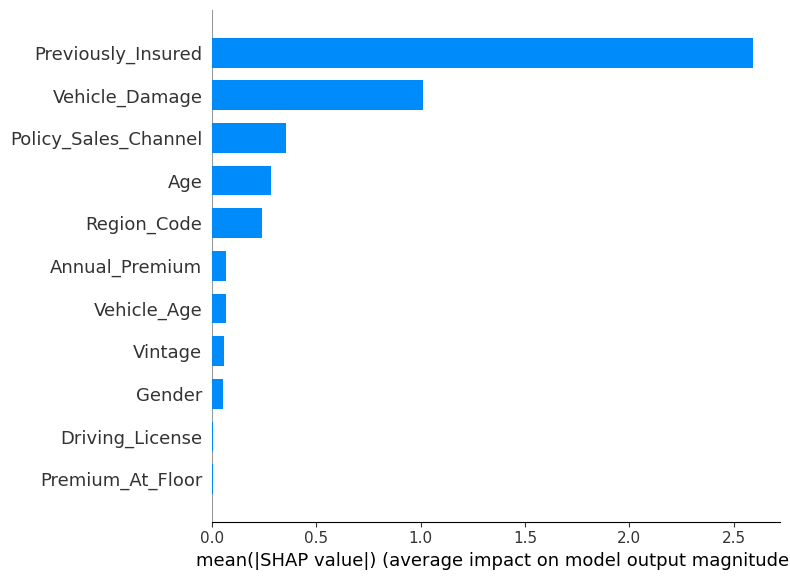

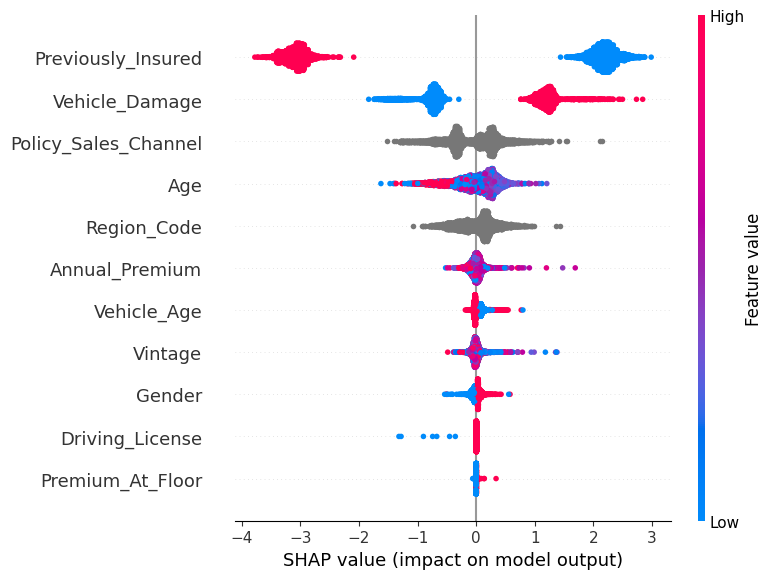

In [ ]:
import shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# SHAP on a random 5,000 test customers (faster, same story)
sample = X_test.sample(5000, random_state=1)
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(sample)
if isinstance(sv, list):
    sv = sv[1]            # the "yes" side
sv = np.array(sv)

# 1. Which columns matter most (share of total influence)
imp = pd.Series(np.abs(sv).mean(axis=0), index=sample.columns).sort_values(ascending=False)
print("Share of influence (%):")
print((imp / imp.sum() * 100).round(1).to_string())

# 2. Explain the highest-scoring customer
i = int(np.argmax(model.predict_proba(sample)[:, 1]))
row = pd.Series(sv[i], index=sample.columns).sort_values(key=abs, ascending=False).head(5)
print("\nHighest-scoring customer, score:", round(model.predict_proba(sample.iloc[[i]])[0, 1], 3))
print(pd.DataFrame({"value": sample.iloc[i][row.index], "push": row.round(2)}))

# 3. Direction check
cols = list(sample.columns)
print("\nAverage push by Vehicle_Damage (0=no, 1=yes):")
print(pd.Series(sv[:, cols.index("Vehicle_Damage")]).groupby(sample["Vehicle_Damage"].values).mean().round(2))
print("\nAverage push by Previously_Insured (0=no, 1=yes):")
print(pd.Series(sv[:, cols.index("Previously_Insured")]).groupby(sample["Previously_Insured"].values).mean().round(2))

# 4. Charts
shap.summary_plot(sv, sample, plot_type="bar")
shap.summary_plot(sv, sample)

In [ ]:
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

PROFIT_PER_SALE, COST_PER_CONTACT = 2000, 100      # same assumptions as Step 4

d = pd.DataFrame({"p": p_test_iso, "y": y_test.values})
d["called"] = d["p"] * PROFIT_PER_SALE - COST_PER_CONTACT > 0

base = d["y"].mean()
targeted_rate = d.loc[d["called"], "y"].mean()
print(f"Buy rate if we call at random: {base:.1%} | if we call only the model's picks: {targeted_rate:.1%}")

# Part 1: how many customers per group to prove the buy rate is higher?
for label, new in [("a small +2 point lift", base + 0.02), ("the lift the model shows", targeted_rate)]:
    es = proportion_effectsize(new, base)
    n = NormalIndPower().solve_power(effect_size=es, alpha=0.05, power=0.80, alternative="two-sided")
    print(f"Customers needed per group to detect {label}: {int(np.ceil(n)):,}")

# Part 2: simulate the real test, judged on PROFIT per customer
profit_control = (d["y"] * PROFIT_PER_SALE - COST_PER_CONTACT).values       # control group: call everyone
profit_targeted = np.where(d["called"], profit_control, 0)                  # test group: call only model picks
print(f"\nAverage profit per customer  Control: Rs {profit_control.mean():.0f} | Targeted: Rs {profit_targeted.mean():.0f}")

rng = np.random.default_rng(42)
sims = 1000
print("\nGroup size -> how often the targeted group wins with 95% confidence")
for N in [500, 1000, 2000, 3000, 4000, 5000]:
    wins = 0
    for _ in range(sims):
        idx = rng.permutation(len(d))
        A, B = profit_control[idx[:N]], profit_targeted[idx[N:2*N]]
        t, pv = stats.ttest_ind(B, A, equal_var=False)
        wins += (pv < 0.05) and (B.mean() > A.mean())
    print(f"{N:>6,} per group -> {wins/sims:.0%}")

Buy rate if we call at random: 12.3% | if we call only the model's picks: 25.5%
Customers needed per group to detect a small +2 point lift: 4,507
Customers needed per group to detect the lift the model shows: 134

Average profit per customer  Control: Rs 145 | Targeted: Rs 193

Group size -> how often the targeted group wins with 95% confidence
   500 per group -> 22%
 1,000 per group -> 37%
 2,000 per group -> 66%
 3,000 per group -> 81%
 4,000 per group -> 92%
 5,000 per group -> 96%


In [ ]:
import numpy as np, pandas as pd
from google.colab import files

out = X_test.copy()
out.insert(0, "Customer_ID", out.index + 1)
out["Gender"] = out["Gender"].map({0: "Female", 1: "Male"})
out["Vehicle_Age_Order"] = out["Vehicle_Age"] + 1
out["Vehicle_Age"] = out["Vehicle_Age"].map({0: "Under 1 year", 1: "1 to 2 years", 2: "Over 2 years"})
out["Vehicle_Damage"] = out["Vehicle_Damage"].map({0: "Never damaged", 1: "Damaged before"})
out["Previously_Insured"] = out["Previously_Insured"].map({0: "Not insured elsewhere", 1: "Already insured"})
out["Annual_Premium"] = out["Annual_Premium"].round(0)
out["Region_Code"] = out["Region_Code"].astype(int)
out["Policy_Sales_Channel"] = out["Policy_Sales_Channel"].astype(int)
out["Age_Group"] = pd.cut(out["Age"], [0, 25, 35, 45, 55, 120],
        labels=["20-24", "25-34", "35-44", "45-54", "55+"], right=False).astype(str)
out["Score"] = p_test_iso.round(6)
band = pd.cut(out["Score"], [-0.001, .05, .1, .2, .3, .4, .5, .6, 1.0],
        labels=["0-5%", "5-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60%+"])
out["Score_Band"] = band.astype(str)
out["Band_Order"] = band.cat.codes + 1
out["Actual_Response"] = y_test.values
out["Decile"] = pd.qcut(out["Score"].rank(method="first", ascending=False), 10, labels=range(1, 11)).astype(int)
out = out.drop(columns=["Driving_License", "Premium_At_Floor"])
out.to_csv("scored_customers.csv", index=False)

fi = (imp / imp.sum() * 100).round(1).reset_index()
fi.columns = ["Feature", "Influence_Pct"]
fi.to_csv("feature_importance.csv", index=False)

pd.DataFrame({"Group_Size": [500, 1000, 2000, 3000, 4000, 5000],
              "Chance_Clear_Win_Pct": [22, 37, 66, 81, 92, 96]}).to_csv("ab_test_power.csv", index=False)

for f in ["scored_customers.csv", "feature_importance.csv", "ab_test_power.csv"]:
    files.download(f)